# 04a — model_offered

**Task:** Predict whether a course will be offered in a given term (binary classifier)  
**Input:** `data/processed/offered_train.csv`, `offered_test.csv`  
**Target:** `offered` (0 = not offered, 1 = offered)  

**Models tested:**
1. Baseline — always predict majority class
2. Logistic Regression
3. K-Nearest Neighbours
4. Random Forest
5. Gradient Boosting

**Selection metric:** AUC-ROC (primary), F1 (tiebreaker)

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
)
from sklearn.calibration import CalibrationDisplay

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

DATA_PATH   = Path('../data/processed')
MODELS_PATH = Path('../models')
FIG_PATH    = Path('../figures/04a_model_offered')
MODELS_PATH.mkdir(exist_ok=True)
FIG_PATH.mkdir(parents=True, exist_ok=True)

FEATURES = [
    'ml_course_id', 'dept_code_enc', 'degree_level_enc', 'course_level', 'units',
    'term_order', 'is_covid_affected',
    'hist_n_offerings', 'hist_n_this_semester_offerings', 'same_semester_offer_ratio',
    'n_distinct_semesters_offered', 'n_terms_since_last_offered',
    'n_consecutive_same_semester_streak',
]
TARGET = 'offered'

print('ready')

ready


---
## 1. Load data

In [2]:
train = pd.read_csv(DATA_PATH / 'offered_train.csv')
test  = pd.read_csv(DATA_PATH / 'offered_test.csv')

X_train = train[FEATURES];  y_train = train[TARGET]
X_test  = test[FEATURES];   y_test  = test[TARGET]

# scale for LR and KNN — fit on train only, apply to test
scaler    = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURES)
X_test_s  = pd.DataFrame(scaler.transform(X_test),      columns=FEATURES)

print(f'X_train: {X_train.shape}  positive rate: {y_train.mean()*100:.1f}%')
print(f'X_test:  {X_test.shape}   positive rate: {y_test.mean()*100:.1f}%')
print(f'features: {len(FEATURES)}')

X_train: (36897, 13)  positive rate: 50.8%
X_test:  (8943, 13)   positive rate: 46.1%
features: 13


---
## 2. Helper functions

In [3]:
results = []

def evaluate_classifier(name, y_true, y_pred, y_prob):
    return {
        'model':     name,
        'accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'auc':       round(roc_auc_score(y_true, y_prob), 4),
        'f1':        round(f1_score(y_true, y_pred, zero_division=0), 4),
        'precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'recall':    round(recall_score(y_true, y_pred, zero_division=0), 4),
    }

def plot_confusion(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not offered','Offered'],
                yticklabels=['Not offered','Offered'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(title)

def plot_roc(ax, y_true, y_prob, name, color):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    ax.plot(fpr, tpr, color=color, lw=1.5, label=f'{name}  AUC={auc:.3f}')
    ax.plot([0,1],[0,1],'k--',lw=0.8)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend()

print('helpers defined')

helpers defined


---
## 3. Baseline

In [4]:
majority_class = int(y_train.mode()[0])
y_base_pred    = np.full(len(y_test), majority_class)
y_base_prob    = np.full(len(y_test), y_train.mean())

base_metrics = evaluate_classifier('Baseline', y_test, y_base_pred, y_base_prob)
results.append(base_metrics)
print(f'Baseline always predicts: {majority_class}')
print(f'Baseline AUC: {base_metrics["auc"]}  — every model must beat this')

Baseline always predicts: 1
Baseline AUC: 0.5  — every model must beat this


---
## 4. Logistic Regression

{'model': 'Logistic Regression', 'accuracy': 0.8161, 'auc': np.float64(0.8996), 'f1': np.float64(0.7981), 'precision': np.float64(0.8084), 'recall': np.float64(0.7882)}


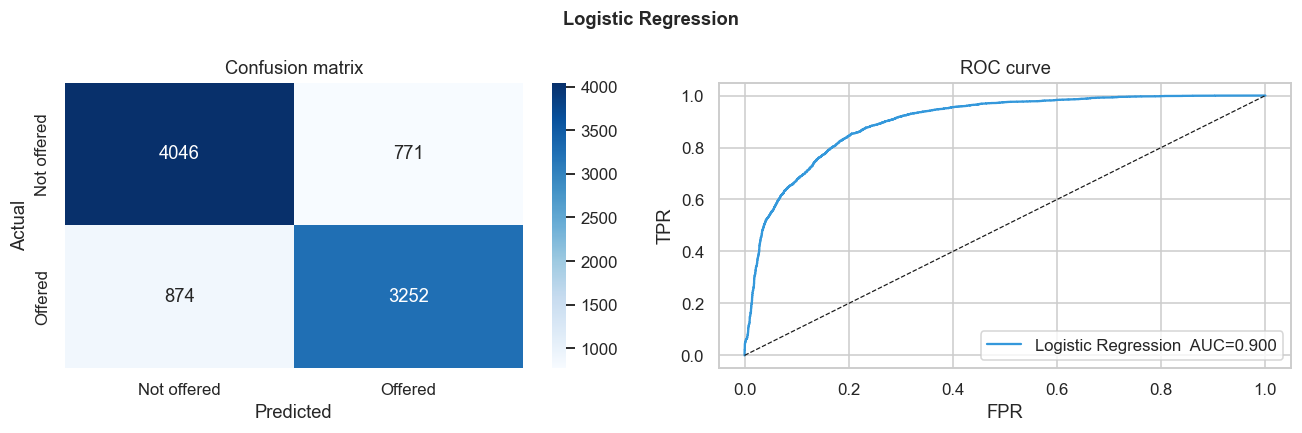

In [5]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_s, y_train)
y_lr_pred = lr.predict(X_test_s)
y_lr_prob = lr.predict_proba(X_test_s)[:, 1]

lr_metrics = evaluate_classifier('Logistic Regression', y_test, y_lr_pred, y_lr_prob)
results.append(lr_metrics)
print(lr_metrics)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Logistic Regression', fontsize=12, fontweight='bold')
plot_confusion(axes[0], y_test, y_lr_pred, 'Confusion matrix')
plot_roc(axes[1], y_test, y_lr_prob, 'Logistic Regression', '#3498db')
axes[1].set_title('ROC curve')
plt.tight_layout()
plt.savefig(FIG_PATH / 'lr.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. K-Nearest Neighbours

{'model': 'KNN', 'accuracy': 0.8312, 'auc': np.float64(0.8962), 'f1': np.float64(0.8151), 'precision': np.float64(0.8236), 'recall': np.float64(0.8068)}


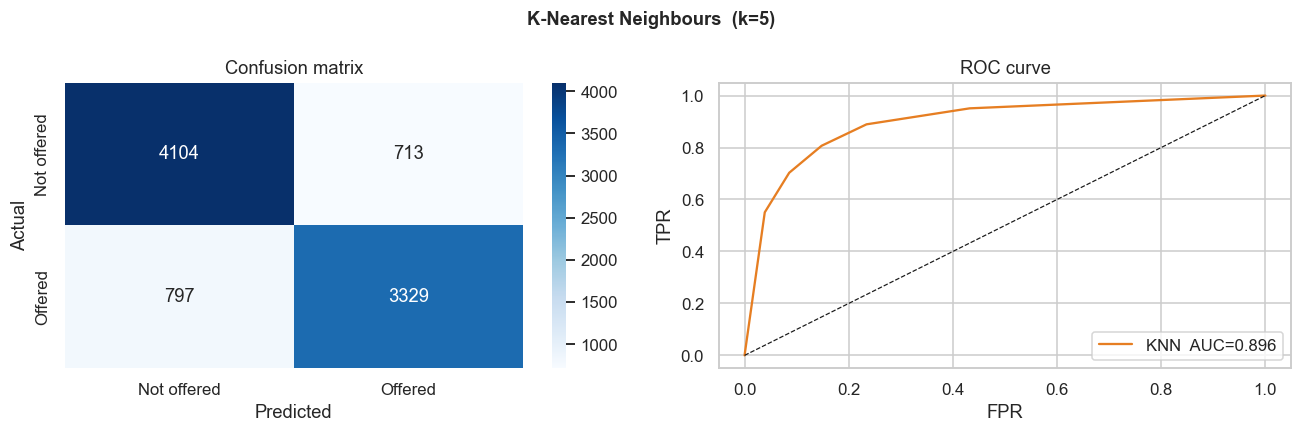

In [6]:
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_train_s, y_train)
y_knn_pred = knn.predict(X_test_s)
y_knn_prob = knn.predict_proba(X_test_s)[:, 1]

knn_metrics = evaluate_classifier('KNN', y_test, y_knn_pred, y_knn_prob)
results.append(knn_metrics)
print(knn_metrics)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('K-Nearest Neighbours  (k=5)', fontsize=12, fontweight='bold')
plot_confusion(axes[0], y_test, y_knn_pred, 'Confusion matrix')
plot_roc(axes[1], y_test, y_knn_prob, 'KNN', '#e67e22')
axes[1].set_title('ROC curve')
plt.tight_layout()
plt.savefig(FIG_PATH / 'knn.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Random Forest

{'model': 'Random Forest', 'accuracy': 0.8358, 'auc': np.float64(0.9159), 'f1': np.float64(0.818), 'precision': np.float64(0.8375), 'recall': np.float64(0.7993)}


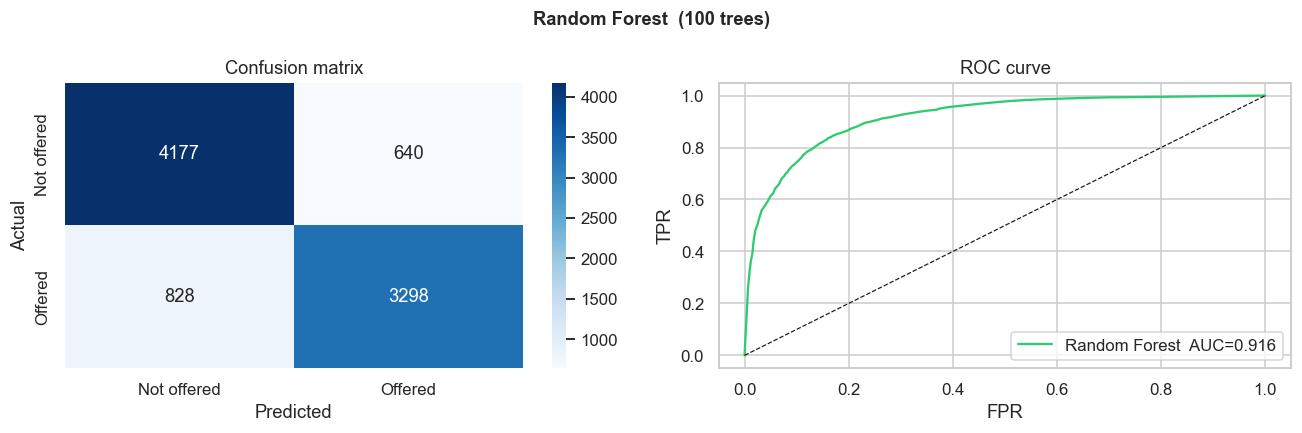

In [7]:
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_rf_pred = rf.predict(X_test)
y_rf_prob = rf.predict_proba(X_test)[:, 1]

rf_metrics = evaluate_classifier('Random Forest', y_test, y_rf_pred, y_rf_prob)
results.append(rf_metrics)
print(rf_metrics)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Random Forest  (100 trees)', fontsize=12, fontweight='bold')
plot_confusion(axes[0], y_test, y_rf_pred, 'Confusion matrix')
plot_roc(axes[1], y_test, y_rf_prob, 'Random Forest', '#2ecc71')
axes[1].set_title('ROC curve')
plt.tight_layout()
plt.savefig(FIG_PATH / 'rf.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Gradient Boosting

{'model': 'Gradient Boosting', 'accuracy': 0.8503, 'auc': np.float64(0.9329), 'f1': np.float64(0.8313), 'precision': np.float64(0.8657), 'recall': np.float64(0.7996)}


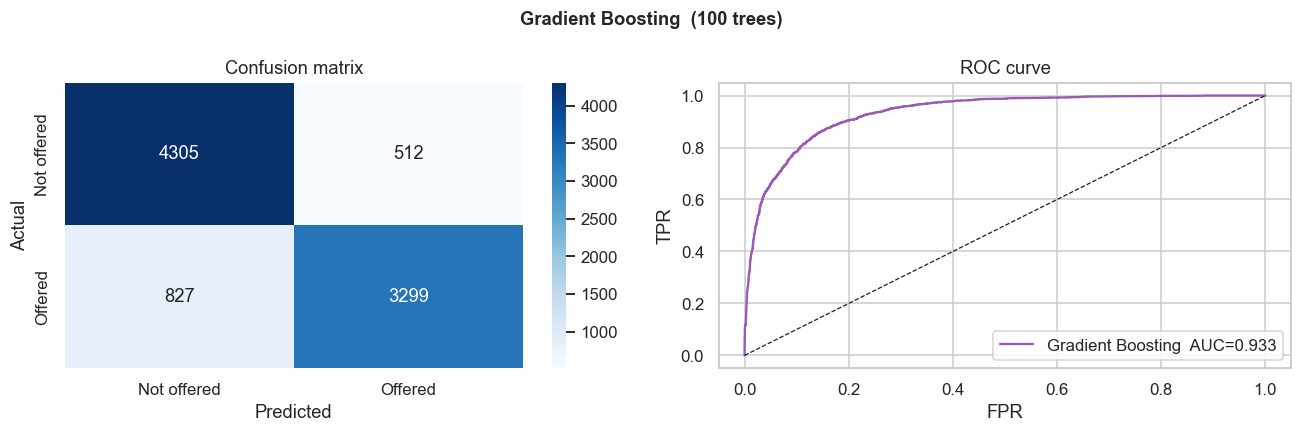

In [8]:
pos_weight     = (y_train == 0).sum() / (y_train == 1).sum()
sample_weights = np.where(y_train == 1, pos_weight, 1.0)

gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)
gb.fit(X_train, y_train, sample_weight=sample_weights)
y_gb_pred = gb.predict(X_test)
y_gb_prob = gb.predict_proba(X_test)[:, 1]

gb_metrics = evaluate_classifier('Gradient Boosting', y_test, y_gb_pred, y_gb_prob)
results.append(gb_metrics)
print(gb_metrics)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Gradient Boosting  (100 trees)', fontsize=12, fontweight='bold')
plot_confusion(axes[0], y_test, y_gb_pred, 'Confusion matrix')
plot_roc(axes[1], y_test, y_gb_prob, 'Gradient Boosting', '#9b59b6')
axes[1].set_title('ROC curve')
plt.tight_layout()
plt.savefig(FIG_PATH / 'gb.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Comparison

=== ALL MODELS ===
                     accuracy     auc      f1  precision  recall
model                                                           
Baseline               0.4614  0.5000  0.6314     0.4614  1.0000
Logistic Regression    0.8161  0.8996  0.7981     0.8084  0.7882
KNN                    0.8312  0.8962  0.8151     0.8236  0.8068
Random Forest          0.8358  0.9159  0.8180     0.8375  0.7993
Gradient Boosting      0.8503  0.9329  0.8313     0.8657  0.7996


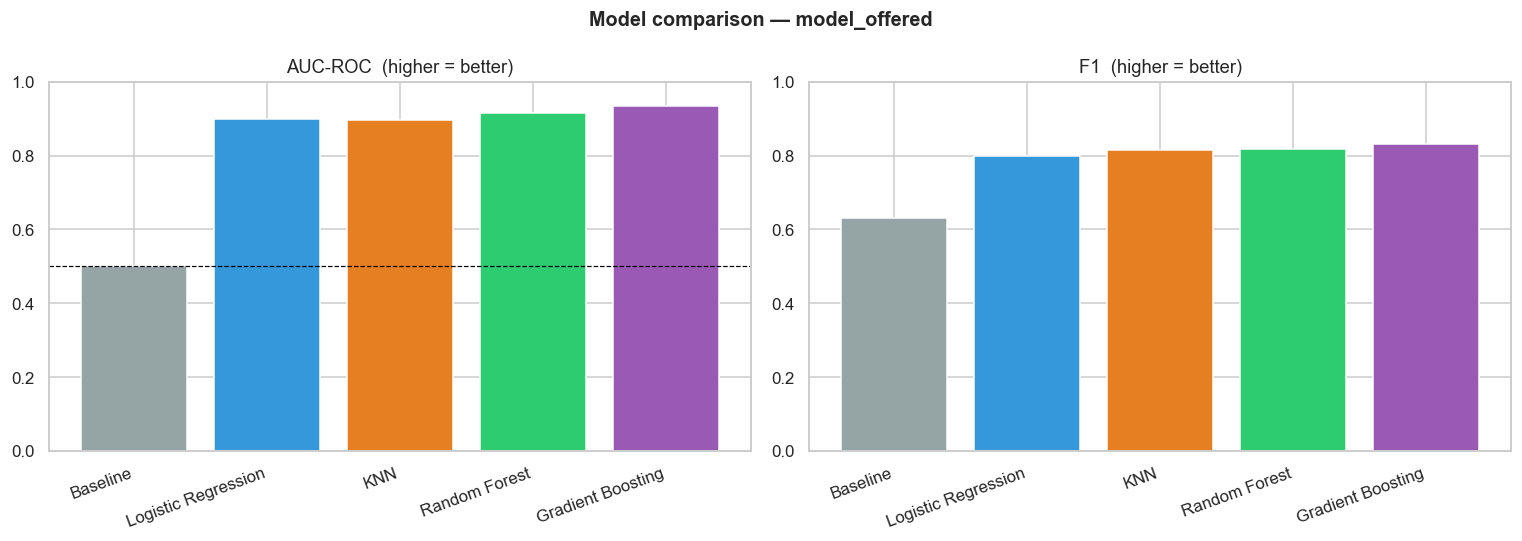

In [9]:
results_df = pd.DataFrame(results).set_index('model')
print('=== ALL MODELS ===')
print(results_df.to_string())

# save results table
results_df.to_csv(DATA_PATH / '04a_results.csv')

colors = ['#95a5a6','#3498db','#e67e22','#2ecc71','#9b59b6']
models = results_df.index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model comparison — model_offered', fontsize=13, fontweight='bold')

axes[0].bar(models, results_df['auc'], color=colors, edgecolor='white')
axes[0].axhline(0.5, color='black', linestyle='--', lw=0.8)
axes[0].set_title('AUC-ROC  (higher = better)')
axes[0].set_ylim(0, 1)
plt.setp(axes[0].get_xticklabels(), rotation=20, ha='right')

axes[1].bar(models, results_df['f1'], color=colors, edgecolor='white')
axes[1].set_title('F1  (higher = better)')
axes[1].set_ylim(0, 1)
plt.setp(axes[1].get_xticklabels(), rotation=20, ha='right')

plt.tight_layout()
plt.savefig(FIG_PATH / 'comparison.png', dpi=150, bbox_inches='tight')
plt.show()

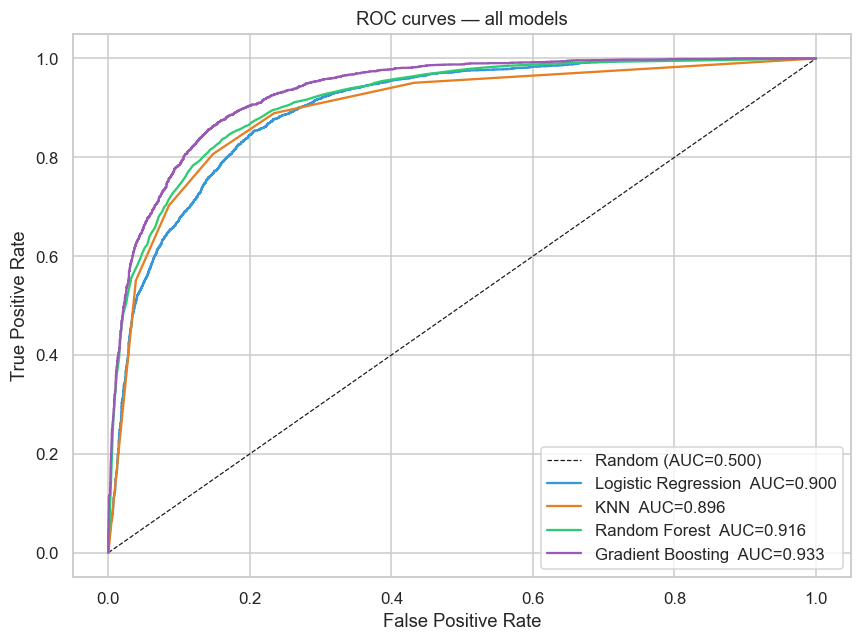

In [10]:
# all 4 ROC curves on one plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0,1],[0,1],'k--',lw=0.8,label='Random (AUC=0.500)')
for name, y_prob, color in [
    ('Logistic Regression', y_lr_prob,  '#3498db'),
    ('KNN',                 y_knn_prob, '#e67e22'),
    ('Random Forest',       y_rf_prob,  '#2ecc71'),
    ('Gradient Boosting',   y_gb_prob,  '#9b59b6'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, lw=1.5, label=f'{name}  AUC={auc:.3f}')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC curves — all models')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_PATH / 'roc_all.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Winner — feature importance + calibration + save

In [11]:
model_map = {
    'Logistic Regression': (lr,  X_test_s, y_lr_pred,  y_lr_prob),
    'KNN':                 (knn, X_test_s, y_knn_pred, y_knn_prob),
    'Random Forest':       (rf,  X_test,   y_rf_pred,  y_rf_prob),
    'Gradient Boosting':   (gb,  X_test,   y_gb_pred,  y_gb_prob),
}

# winner = highest AUC, F1 as tiebreaker
non_base = results_df.drop('Baseline')
max_auc  = non_base['auc'].max()
tied     = non_base[non_base['auc'] == max_auc]
best_row = tied['f1'].idxmax()

best_model, best_X_test, best_pred, best_prob = model_map[best_row]

print(f'Winner: {best_row}')
print(f'  AUC: {results_df.loc[best_row, "auc"]}')
print(f'  F1:  {results_df.loc[best_row, "f1"]}')

Winner: Gradient Boosting
  AUC: 0.9329
  F1:  0.8313


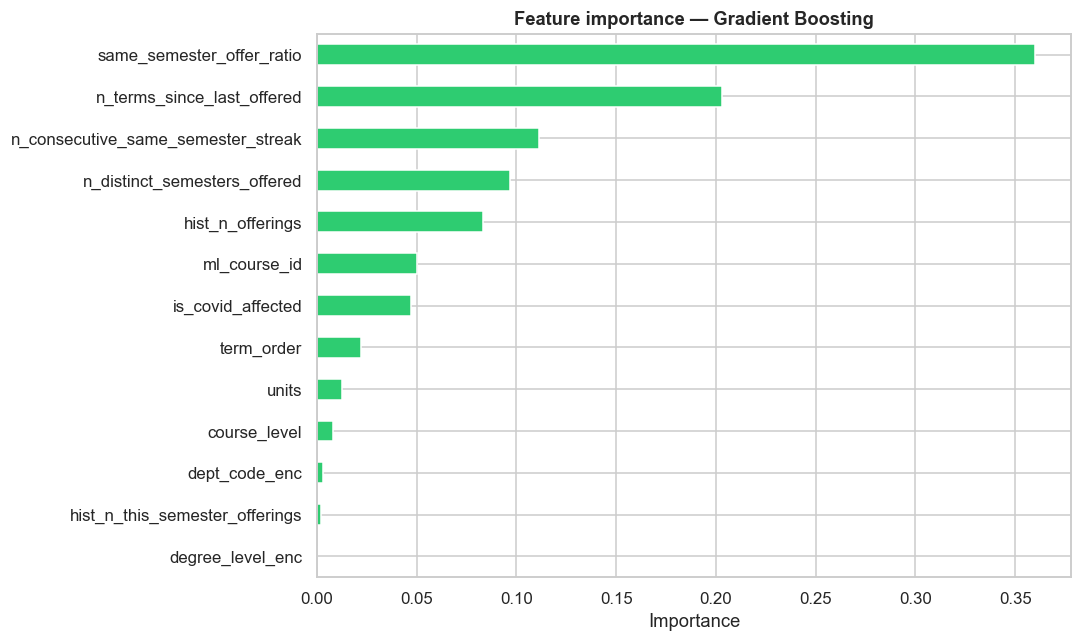

In [12]:
# feature importance — tree models only
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values()
    fig, ax = plt.subplots(figsize=(10, 6))
    importances.plot(kind='barh', ax=ax, color='#2ecc71', edgecolor='white')
    ax.set_title(f'Feature importance — {best_row}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.savefig(FIG_PATH / 'winner_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f'{best_row} has no feature_importances_')

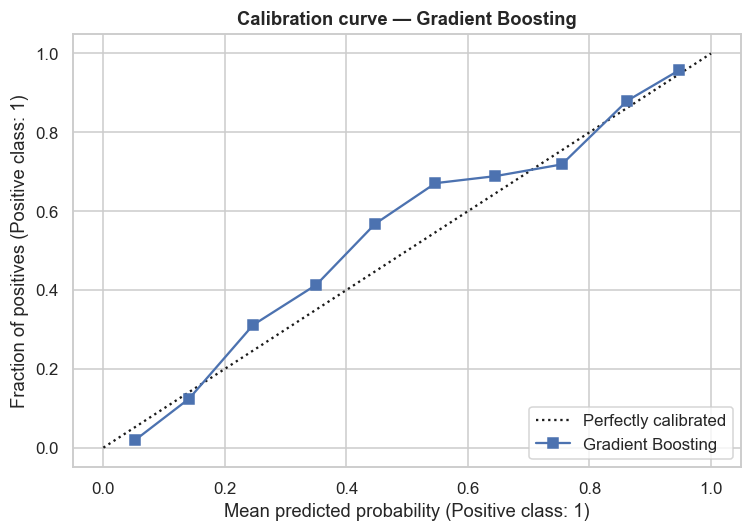

Points close to diagonal = well calibrated probabilities


In [13]:
# calibration curve
fig, ax = plt.subplots(figsize=(7, 5))
CalibrationDisplay.from_estimator(best_model, best_X_test, y_test, n_bins=10, ax=ax, name=best_row)
ax.set_title(f'Calibration curve — {best_row}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_PATH / 'winner_calibration.png', dpi=150, bbox_inches='tight')
plt.show()
print('Points close to diagonal = well calibrated probabilities')

In [14]:
print(f'--- {best_row} classification report ---')
print(classification_report(y_test, best_pred, target_names=['Not offered','Offered']))

--- Gradient Boosting classification report ---
              precision    recall  f1-score   support

 Not offered       0.84      0.89      0.87      4817
     Offered       0.87      0.80      0.83      4126

    accuracy                           0.85      8943
   macro avg       0.85      0.85      0.85      8943
weighted avg       0.85      0.85      0.85      8943



In [15]:
joblib.dump(best_model, MODELS_PATH / 'model_offered.pkl')
joblib.dump(scaler,     MODELS_PATH / 'scaler_offered.pkl')
print(f'saved: model_offered.pkl  ({best_row})')
print(f'saved: scaler_offered.pkl')

saved: model_offered.pkl  (Gradient Boosting)
saved: scaler_offered.pkl
